In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, pow as spark_pow
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import GeneralizedLinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import os

np.random.seed(42)

In [2]:
spark = SparkSession.builder.appName("Assignment04_Lightcast").getOrCreate()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/31 19:54:20 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
df = spark.read.option("header", "true") \
    .option("inferSchema", "true") \
    .option("multiLine", "true") \
    .option("escape", "\"") \
    .csv("data/lightcast_job_postings.csv")

print("--- Diagnostic check ---")
df.printSchema()
df.show(5, truncate=False)
print("Row count:", df.count())
print("Column count:", len(df.columns))

--- Diagnostic check ---
root
 |-- ID: string (nullable = true)
 |-- LAST_UPDATED_DATE: string (nullable = true)
 |-- LAST_UPDATED_TIMESTAMP: timestamp (nullable = true)
 |-- DUPLICATES: integer (nullable = true)
 |-- POSTED: string (nullable = true)
 |-- EXPIRED: string (nullable = true)
 |-- DURATION: integer (nullable = true)
 |-- SOURCE_TYPES: string (nullable = true)
 |-- SOURCES: string (nullable = true)
 |-- URL: string (nullable = true)
 |-- ACTIVE_URLS: string (nullable = true)
 |-- ACTIVE_SOURCES_INFO: string (nullable = true)
 |-- TITLE_RAW: string (nullable = true)
 |-- BODY: string (nullable = true)
 |-- MODELED_EXPIRED: string (nullable = true)
 |-- MODELED_DURATION: integer (nullable = true)
 |-- COMPANY: integer (nullable = true)
 |-- COMPANY_NAME: string (nullable = true)
 |-- COMPANY_RAW: string (nullable = true)
 |-- COMPANY_IS_STAFFING: boolean (nullable = true)
 |-- EDUCATION_LEVELS: string (nullable = true)
 |-- EDUCATION_LEVELS_NAME: string (nullable = true)
 |--

26/03/31 19:55:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+----------------------------------------+-----------------+-----------------------+----------+--------+---------+--------+----------------------+---------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+-----------+-------------------+------------------------------------------------------------+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

Row count: 72498
Column count: 131


In [4]:
selected_cols = [
    "SALARY",
    "MIN_YEARS_EXPERIENCE",
    "MAX_YEARS_EXPERIENCE",
    "DURATION",
    "SALARY_FROM",
    "EDUCATION_LEVELS_NAME",
    "REMOTE_TYPE_NAME"
]

df_model = df.select(*selected_cols)
df_model.show(5, truncate=False)

+------+--------------------+--------------------+--------+-----------+-----------------------------+----------------+
|SALARY|MIN_YEARS_EXPERIENCE|MAX_YEARS_EXPERIENCE|DURATION|SALARY_FROM|EDUCATION_LEVELS_NAME        |REMOTE_TYPE_NAME|
+------+--------------------+--------------------+--------+-----------+-----------------------------+----------------+
|NULL  |2                   |2                   |6       |NULL       |[\n  "Bachelor's degree"\n]  |[None]          |
|NULL  |3                   |3                   |NULL    |NULL       |[\n  "No Education Listed"\n]|Remote          |
|NULL  |5                   |NULL                |35      |NULL       |[\n  "Bachelor's degree"\n]  |[None]          |
|NULL  |3                   |NULL                |48      |NULL       |[\n  "No Education Listed"\n]|[None]          |
|92500 |NULL                |NULL                |15      |35000      |[\n  "No Education Listed"\n]|[None]          |
+------+--------------------+-------------------

In [5]:
df_clean = df_model.dropna(subset=[
    "SALARY",
    "MIN_YEARS_EXPERIENCE",
    "MAX_YEARS_EXPERIENCE",
    "DURATION",
    "SALARY_FROM",
    "EDUCATION_LEVELS_NAME",
    "REMOTE_TYPE_NAME"
])

df_clean = df_clean.filter(col("SALARY") > 0) \
                   .filter(col("MIN_YEARS_EXPERIENCE") >= 0) \
                   .filter(col("MAX_YEARS_EXPERIENCE") >= 0) \
                   .filter(col("DURATION") >= 0) \
                   .filter(col("SALARY_FROM") >= 0)

print("Rows after cleaning:", df_clean.count())
df_clean.show(5, truncate=False)

Rows after cleaning: 2243
+------+--------------------+--------------------+--------+-----------+------------------------------------------------------------------------------------+----------------+
|SALARY|MIN_YEARS_EXPERIENCE|MAX_YEARS_EXPERIENCE|DURATION|SALARY_FROM|EDUCATION_LEVELS_NAME                                                               |REMOTE_TYPE_NAME|
+------+--------------------+--------------------+--------+-----------+------------------------------------------------------------------------------------+----------------+
|131100|2                   |2                   |11      |113400     |[\n  "Bachelor's degree"\n]                                                         |[None]          |
|136950|3                   |3                   |28      |115300     |[\n  "Bachelor's degree",\n  "Master's degree",\n  "Ph.D. or professional degree"\n]|Remote          |
|136950|3                   |3                   |28      |115300     |[\n  "Bachelor's degree",\n  "Mas

In [6]:
df_clean = df_clean.withColumn(
    "MIN_YEARS_EXPERIENCE_SQ",
    spark_pow(col("MIN_YEARS_EXPERIENCE"), 2)
)

df_clean.select(
    "MIN_YEARS_EXPERIENCE",
    "MIN_YEARS_EXPERIENCE_SQ"
).show(5)

+--------------------+-----------------------+
|MIN_YEARS_EXPERIENCE|MIN_YEARS_EXPERIENCE_SQ|
+--------------------+-----------------------+
|                   2|                    4.0|
|                   3|                    9.0|
|                   3|                    9.0|
|                   3|                    9.0|
|                   3|                    9.0|
+--------------------+-----------------------+
only showing top 5 rows


In [7]:
df_clean = df_clean.withColumn(
    "MIN_YEARS_EXPERIENCE_SQ",
    spark_pow(col("MIN_YEARS_EXPERIENCE"), 2)
)

df_clean.select(
    "MIN_YEARS_EXPERIENCE",
    "MIN_YEARS_EXPERIENCE_SQ"
).show(5)

+--------------------+-----------------------+
|MIN_YEARS_EXPERIENCE|MIN_YEARS_EXPERIENCE_SQ|
+--------------------+-----------------------+
|                   2|                    4.0|
|                   3|                    9.0|
|                   3|                    9.0|
|                   3|                    9.0|
|                   3|                    9.0|
+--------------------+-----------------------+
only showing top 5 rows


In [8]:
categorical_cols = ["EDUCATION_LEVELS_NAME", "REMOTE_TYPE_NAME"]
continuous_cols = [
    "MIN_YEARS_EXPERIENCE",
    "MAX_YEARS_EXPERIENCE",
    "DURATION",
    "SALARY_FROM"
]

indexers = [
    StringIndexer(
        inputCol=c,
        outputCol=f"{c}_idx",
        handleInvalid="keep"
    ) for c in categorical_cols
]

encoders = [
    OneHotEncoder(
        inputCol=f"{c}_idx",
        outputCol=f"{c}_vec"
    ) for c in categorical_cols
]

feature_cols = continuous_cols + [f"{c}_vec" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

feature_cols_poly = [
    "MIN_YEARS_EXPERIENCE",
    "MIN_YEARS_EXPERIENCE_SQ",
    "MAX_YEARS_EXPERIENCE",
    "DURATION",
    "SALARY_FROM"
] + [f"{c}_vec" for c in categorical_cols]

assembler_poly = VectorAssembler(
    inputCols=feature_cols_poly,
    outputCol="features_poly"
)

pipeline = Pipeline(stages=indexers + encoders + [assembler, assembler_poly])
pipeline_model = pipeline.fit(df_clean)
df_final = pipeline_model.transform(df_clean)

df_final.select("SALARY", "features", "features_poly").show(5, truncate=False)

+------+---------------------------------------------------+---------------------------------------------------------+
|SALARY|features                                           |features_poly                                            |
+------+---------------------------------------------------+---------------------------------------------------------+
|131100|(26,[0,1,2,3,4,22],[2.0,2.0,11.0,113400.0,1.0,1.0])|(27,[0,1,2,3,4,5,23],[2.0,4.0,2.0,11.0,113400.0,1.0,1.0])|
|136950|(26,[0,1,2,3,8,23],[3.0,3.0,28.0,115300.0,1.0,1.0])|(27,[0,1,2,3,4,9,24],[3.0,9.0,3.0,28.0,115300.0,1.0,1.0])|
|136950|(26,[0,1,2,3,8,23],[3.0,3.0,28.0,115300.0,1.0,1.0])|(27,[0,1,2,3,4,9,24],[3.0,9.0,3.0,28.0,115300.0,1.0,1.0])|
|104000|(26,[0,1,2,3,4,22],[3.0,3.0,8.0,104000.0,1.0,1.0]) |(27,[0,1,2,3,4,5,23],[3.0,9.0,3.0,8.0,104000.0,1.0,1.0]) |
|80000 |(26,[0,1,2,3,4,22],[3.0,3.0,37.0,60000.0,1.0,1.0]) |(27,[0,1,2,3,4,5,23],[3.0,9.0,3.0,37.0,60000.0,1.0,1.0]) |
+------+----------------------------------------

In [9]:
train_df, test_df = df_final.randomSplit([0.8, 0.2], seed=42)

print("Training rows:", train_df.count())
print("Testing rows:", test_df.count())

Training rows: 1848


Testing rows: 395


In [12]:
glr = GeneralizedLinearRegression(
    featuresCol="features",
    labelCol="SALARY",
    family="gaussian",
    link="identity",
    maxIter=50,
    regParam=0.0
)

glr_model = glr.fit(train_df)
glr_summary = glr_model.summary

print("GLR Intercept:", glr_model.intercept)
print("GLR Coefficients:", glr_model.coefficients)
print("GLR AIC:", glr_summary.aic)
print("GLR Deviance:", glr_summary.deviance)
print("GLR Dispersion:", glr_summary.dispersion)

26/03/31 20:03:00 WARN Instrumentation: [4e49795d] regParam is zero, which might cause numerical instability and overfitting.
26/03/31 20:03:05 WARN Instrumentation: [4e49795d] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.
26/03/31 20:03:05 ERROR LBFGS: Failure! Resetting history: breeze.optimize.FirstOrderException: Line search zoom failed


GLR Intercept: 14513.377068957152
GLR Coefficients: [992.8046346802313,992.8046346802313,38.97798682179655,0.9152507815901666,-103.78094213954445,-1862.0408698230754,3584.4396620641173,-6655.729131993214,7234.311657913028,-9652.13637289093,-6391.992836933192,7501.752708106512,-9826.575057854894,14015.519198459042,3509.7015358015383,4062.865157879691,-9323.755790153347,-11321.235328676872,-4578.583357619621,-6996.22697941996,-9428.025813442715,4275.224556098246,-94.37297013681918,-119.01988705217694,1008.0507493124787,1828.7863029033301]


GLR AIC: 39989.08072885699
GLR Deviance: 262309805005.9645
GLR Dispersion: 144047119.717718


In [13]:
glr_train_pred = glr_model.transform(train_df)
glr_test_pred = glr_model.transform(test_df)

evaluator_r2 = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction",
    metricName="r2"
)

evaluator_rmse = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction",
    metricName="rmse"
)

evaluator_mae = RegressionEvaluator(
    labelCol="SALARY",
    predictionCol="prediction",
    metricName="mae"
)

print("GLR Train R2:", evaluator_r2.evaluate(glr_train_pred))
print("GLR Test R2:", evaluator_r2.evaluate(glr_test_pred))
print("GLR Train RMSE:", evaluator_rmse.evaluate(glr_train_pred))
print("GLR Test RMSE:", evaluator_rmse.evaluate(glr_test_pred))
print("GLR Train MAE:", evaluator_mae.evaluate(glr_train_pred))
print("GLR Test MAE:", evaluator_mae.evaluate(glr_test_pred))

GLR Train R2: 0.8853377647427626


GLR Test R2: 0.8918105256452091


GLR Train RMSE: 11913.96387338772


GLR Test RMSE: 10979.630413848623


GLR Train MAE: 8755.037654956333


GLR Test MAE: 8378.173033275407


regParam is zero, which might cause numerical instability and overfitting
Cholesky solver failed due to singular covariance matrix
Retrying with Quasi-Newton solver

In [15]:

glr_feature_names = continuous_cols.copy()

for c in categorical_cols:
    vec_size = df_final.select(f"{c}_vec").first()[0].size
    glr_feature_names.extend([f"{c}_vec_{i}" for i in range(vec_size)])

print("Length of features:", len(glr_feature_names))
print("Length of coefs:", len(glr_model.coefficients))

try:
    se = list(glr_summary.coefficientStandardErrors)[1:]
    tvals = list(glr_summary.tValues)[1:]
    pvals = list(glr_summary.pValues)[1:]
    
    print("Length of se:", len(se))
    print("Length of tvals:", len(tvals))
    print("Length of pvals:", len(pvals))
    
except Exception as e:
    print("Standard errors / t-values / p-values not available for this GLR fit.")
    print("Reason:", str(e))

Length of features: 26
Length of coefs: 26
Standard errors / t-values / p-values not available for this GLR fit.
Reason: No Std. Error of coefficients available for this GeneralizedLinearRegressionModel


Due to numerical instability and solver fallback in PySpark’s generalized linear regression fitting process, coefficient-level inferential statistics such as standard errors, t-values, and p-values were not fully available in this run. However, coefficient estimates, AIC, deviance, and out-of-sample predictive metrics were still used for model evaluation.

In [16]:
coef_list = list(glr_model.coefficients)

try:
    se = list(glr_summary.coefficientStandardErrors)[1:]
    tvals = list(glr_summary.tValues)[1:]
    pvals = list(glr_summary.pValues)[1:]

    glr_coef_df = pd.DataFrame({
        "Feature": glr_feature_names,
        "Estimate": coef_list,
        "Std_Error": se,
        "t_value": tvals,
        "p_value": pvals
    })

    glr_coef_df["CI_Lower"] = glr_coef_df["Estimate"] - 1.96 * glr_coef_df["Std_Error"]
    glr_coef_df["CI_Upper"] = glr_coef_df["Estimate"] + 1.96 * glr_coef_df["Std_Error"]

    glr_intercept_df = pd.DataFrame({
        "Feature": ["Intercept"],
        "Estimate": [glr_model.intercept],
        "Std_Error": [glr_summary.coefficientStandardErrors[0]],
        "t_value": [glr_summary.tValues[0]],
        "p_value": [glr_summary.pValues[0]],
        "CI_Lower": [glr_model.intercept - 1.96 * glr_summary.coefficientStandardErrors[0]],
        "CI_Upper": [glr_model.intercept + 1.96 * glr_summary.coefficientStandardErrors[0]]
    })

    glr_results_table = pd.concat([glr_intercept_df, glr_coef_df], ignore_index=True)

except Exception:
    glr_results_table = pd.DataFrame({
        "Feature": ["Intercept"] + glr_feature_names,
        "Estimate": [glr_model.intercept] + coef_list
    })

glr_results_table

,Feature,Estimate
0,Intercept,14513.377069
1,MIN_YEARS_EXPERIENCE,992.804635
2,MAX_YEARS_EXPERIENCE,992.804635
3,DURATION,38.977987
4,SALARY_FROM,0.915251
5,EDUCATION_LEVELS_NAME_vec_0,-103.780942
6,EDUCATION_LEVELS_NAME_vec_1,-1862.040870
7,EDUCATION_LEVELS_NAME_vec_2,3584.439662
8,EDUCATION_LEVELS_NAME_vec_3,-6655.729132
9,EDUCATION_LEVELS_NAME_vec_4,7234.311658


In [17]:
glr_poly = GeneralizedLinearRegression(
    featuresCol="features_poly",
    labelCol="SALARY",
    family="gaussian",
    link="identity",
    maxIter=50,
    regParam=0.0
)

glr_poly_model = glr_poly.fit(train_df)
glr_poly_summary = glr_poly_model.summary

print("Polynomial Intercept:", glr_poly_model.intercept)
print("Polynomial Coefficients:", glr_poly_model.coefficients)
print("Polynomial AIC:", glr_poly_summary.aic)
print("Polynomial Deviance:", glr_poly_summary.deviance)
print("Polynomial Dispersion:", glr_poly_summary.dispersion)

26/03/31 20:12:32 WARN Instrumentation: [f0c937d8] regParam is zero, which might cause numerical instability and overfitting.
26/03/31 20:12:38 WARN Instrumentation: [f0c937d8] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


Polynomial Intercept: 12756.166492157252
Polynomial Coefficients: [1636.8599838690127,-132.15051902111657,1636.8599838690127,40.938401893897264,0.9110158846544467,-209.39614909382982,-1808.7663800092378,3586.449845028134,-6681.459641335503,6659.24749156667,-9520.790112124709,-6311.7320196505925,7876.048646649265,-10162.016889855478,19394.837377860607,4149.109790221259,4194.077609801843,-9728.904577057183,-12047.777036375432,-4644.0780508293465,-6921.674327670528,-8672.773115448355,6550.0330662566275,-153.14725277430117,-76.65620474341088,1146.74481826377,1942.0093580975501]


Polynomial AIC: 39979.33444487061
Polynomial Deviance: 260647795318.51996
Polynomial Dispersion: 143213074.35083514


In [18]:
poly_train_pred = glr_poly_model.transform(train_df)
poly_test_pred = glr_poly_model.transform(test_df)

print("Polynomial Train R2:", evaluator_r2.evaluate(poly_train_pred))
print("Polynomial Test R2:", evaluator_r2.evaluate(poly_test_pred))
print("Polynomial Train RMSE:", evaluator_rmse.evaluate(poly_train_pred))
print("Polynomial Test RMSE:", evaluator_rmse.evaluate(poly_test_pred))
print("Polynomial Train MAE:", evaluator_mae.evaluate(poly_train_pred))
print("Polynomial Test MAE:", evaluator_mae.evaluate(poly_test_pred))

Polynomial Train R2: 0.8860642711186003


Polynomial Test R2: 0.8921878738879978


Polynomial Train RMSE: 11876.160123748476


Polynomial Test RMSE: 10960.466057776675


Polynomial Train MAE: 8748.367577005825


Polynomial Test MAE: 8343.825163948974


In [20]:

poly_feature_names = [
    "MIN_YEARS_EXPERIENCE",
    "MIN_YEARS_EXPERIENCE_SQ",
    "MAX_YEARS_EXPERIENCE",
    "DURATION",
    "SALARY_FROM"
]

for c in categorical_cols:
    vec_size = df_final.select(f"{c}_vec").first()[0].size
    poly_feature_names.extend([f"{c}_vec_{i}" for i in range(vec_size)])

print("Length of features:", len(poly_feature_names))
print("Length of coefs:", len(glr_poly_model.coefficients))

try:
    poly_se = list(glr_poly_summary.coefficientStandardErrors)[1:]
    poly_tvals = list(glr_poly_summary.tValues)[1:]
    poly_pvals = list(glr_poly_summary.pValues)[1:]

    print("Length of se:", len(poly_se))
    print("Length of tvals:", len(poly_tvals))
    print("Length of pvals:", len(poly_pvals))

except Exception as e:
    print("Standard errors / t-values / p-values not available for this polynomial GLR fit.")
    print("Reason:", str(e))

Length of features: 27
Length of coefs: 27
Standard errors / t-values / p-values not available for this polynomial GLR fit.
Reason: No Std. Error of coefficients available for this GeneralizedLinearRegressionModel


Due to numerical instability and solver fallback in the generalized linear regression fitting process, some inferential statistics such as standard errors, t-values, and p-values were not available for all fitted specifications. Therefore, the final comparison emphasized coefficient estimates, AIC/deviance where available, and out-of-sample predictive metrics such as test R², RMSE, and MAE.

In [21]:
poly_coef_list = list(glr_poly_model.coefficients)

try:
    poly_se = list(glr_poly_summary.coefficientStandardErrors)[1:]
    poly_tvals = list(glr_poly_summary.tValues)[1:]
    poly_pvals = list(glr_poly_summary.pValues)[1:]

    poly_coef_df = pd.DataFrame({
        "Feature": poly_feature_names,
        "Estimate": poly_coef_list,
        "Std_Error": poly_se,
        "t_value": poly_tvals,
        "p_value": poly_pvals
    })

    poly_coef_df["CI_Lower"] = poly_coef_df["Estimate"] - 1.96 * poly_coef_df["Std_Error"]
    poly_coef_df["CI_Upper"] = poly_coef_df["Estimate"] + 1.96 * poly_coef_df["Std_Error"]

    poly_intercept_df = pd.DataFrame({
        "Feature": ["Intercept"],
        "Estimate": [glr_poly_model.intercept],
        "Std_Error": [glr_poly_summary.coefficientStandardErrors[0]],
        "t_value": [glr_poly_summary.tValues[0]],
        "p_value": [glr_poly_summary.pValues[0]],
        "CI_Lower": [glr_poly_model.intercept - 1.96 * glr_poly_summary.coefficientStandardErrors[0]],
        "CI_Upper": [glr_poly_model.intercept + 1.96 * glr_poly_summary.coefficientStandardErrors[0]]
    })

    poly_results_table = pd.concat([poly_intercept_df, poly_coef_df], ignore_index=True)

except Exception:
    poly_results_table = pd.DataFrame({
        "Feature": ["Intercept"] + poly_feature_names,
        "Estimate": [glr_poly_model.intercept] + poly_coef_list
    })

poly_results_table

,Feature,Estimate
0,Intercept,12756.166492
1,MIN_YEARS_EXPERIENCE,1636.859984
2,MIN_YEARS_EXPERIENCE_SQ,-132.150519
3,MAX_YEARS_EXPERIENCE,1636.859984
4,DURATION,40.938402
5,SALARY_FROM,0.911016
6,EDUCATION_LEVELS_NAME_vec_0,-209.396149
7,EDUCATION_LEVELS_NAME_vec_1,-1808.766380
8,EDUCATION_LEVELS_NAME_vec_2,3586.449845
9,EDUCATION_LEVELS_NAME_vec_3,-6681.459641


In [22]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="SALARY",
    numTrees=200,
    maxDepth=8,
    seed=42
)

rf_model = rf.fit(train_df)

26/03/31 20:22:54 WARN DAGScheduler: Broadcasting large task binary with size 1125.3 KiB
26/03/31 20:22:55 WARN DAGScheduler: Broadcasting large task binary with size 1928.3 KiB
26/03/31 20:22:56 WARN DAGScheduler: Broadcasting large task binary with size 3.1 MiB
26/03/31 20:22:59 WARN DAGScheduler: Broadcasting large task binary with size 4.9 MiB


In [23]:
rf_train_pred = rf_model.transform(train_df)
rf_test_pred = rf_model.transform(test_df)

print("RF Train R2:", evaluator_r2.evaluate(rf_train_pred))
print("RF Test R2:", evaluator_r2.evaluate(rf_test_pred))
print("RF Train RMSE:", evaluator_rmse.evaluate(rf_train_pred))
print("RF Test RMSE:", evaluator_rmse.evaluate(rf_test_pred))
print("RF Train MAE:", evaluator_mae.evaluate(rf_train_pred))
print("RF Test MAE:", evaluator_mae.evaluate(rf_test_pred))

RF Train R2: 0.9222692442350224


RF Test R2: 0.9082439467903414


RF Train RMSE: 9809.401759729184


RF Test RMSE: 10111.429972213538


RF Train MAE: 6711.454459296192


RF Test MAE: 7304.295582081861


In [24]:
rf_importances = rf_model.featureImportances.toArray()

print("Length of feature names:", len(glr_feature_names))
print("Length of importances:", len(rf_importances))

Length of feature names: 26
Length of importances: 26


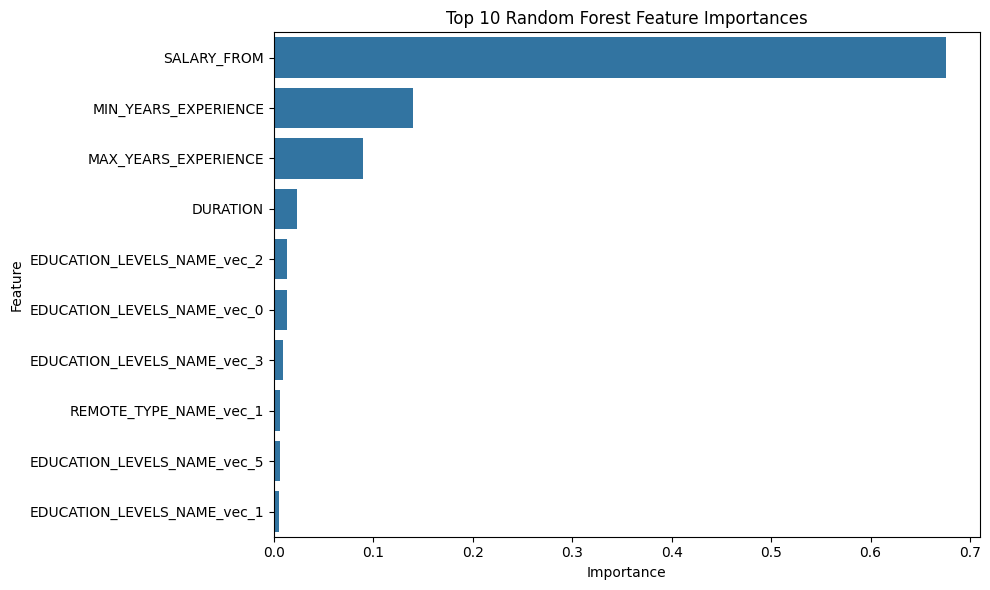

,Feature,Importance
3,SALARY_FROM,0.675781
0,MIN_YEARS_EXPERIENCE,0.139761
1,MAX_YEARS_EXPERIENCE,0.089947
2,DURATION,0.022819
6,EDUCATION_LEVELS_NAME_vec_2,0.013324
4,EDUCATION_LEVELS_NAME_vec_0,0.012828
7,EDUCATION_LEVELS_NAME_vec_3,0.009538
23,REMOTE_TYPE_NAME_vec_1,0.006293
9,EDUCATION_LEVELS_NAME_vec_5,0.006093
5,EDUCATION_LEVELS_NAME_vec_1,0.005379


In [25]:
os.makedirs("_output", exist_ok=True)

rf_importance_df = pd.DataFrame({
    "Feature": glr_feature_names,
    "Importance": rf_importances
}).sort_values("Importance", ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(data=rf_importance_df, x="Importance", y="Feature")
plt.title("Top 10 Random Forest Feature Importances")
plt.tight_layout()
plt.savefig("_output/rf_feature_importance.png", dpi=300, bbox_inches="tight")
plt.show()

rf_importance_df

In [26]:
glr_test_pred = glr_model.transform(test_df)
poly_test_pred = glr_poly_model.transform(test_df)
rf_test_pred = rf_model.transform(test_df)

glr_pd = glr_test_pred.select("SALARY", col("prediction").alias("GLR_Pred")).toPandas()
poly_pd = poly_test_pred.select(col("prediction").alias("POLY_Pred")).toPandas()
rf_pd = rf_test_pred.select(col("prediction").alias("RF_Pred")).toPandas()

pred_pd = pd.concat([glr_pd.reset_index(drop=True), poly_pd, rf_pd], axis=1)
pred_pd.head()

,SALARY,GLR_Pred,POLY_Pred,RF_Pred
0,35360,37913.626769,37279.298451,52048.160786
1,39520,43858.659567,43209.667983,51732.167362
2,39655,43162.111030,42490.653189,51839.569312
3,42848,42246.282298,42253.243086,52840.545484
4,43680,57441.807591,57588.786206,62824.581935


In [27]:
def calculate_bic_from_glr(summary, k, n):
    deviance = summary.deviance
    dispersion = summary.dispersion
    
    log_likelihood = -0.5 * (
        n * math.log(2 * math.pi) +
        n * math.log(dispersion) +
        (deviance / dispersion)
    )
    
    bic = k * math.log(n) - 2 * log_likelihood
    return log_likelihood, bic

n_test = test_df.count()

glr_k = len(glr_model.coefficients) + 1
poly_k = len(glr_poly_model.coefficients) + 1

glr_loglik, glr_bic = calculate_bic_from_glr(glr_summary, glr_k, n_test)
poly_loglik, poly_bic = calculate_bic_from_glr(glr_poly_summary, poly_k, n_test)

print("GLR BIC:", glr_bic)
print("Polynomial BIC:", poly_bic)

GLR BIC: 10128.723511473569
Polynomial BIC: 10131.408665962947


In [28]:
def calculate_bic_from_glr(summary, k, n):
    deviance = summary.deviance
    dispersion = summary.dispersion
    
    log_likelihood = -0.5 * (
        n * math.log(2 * math.pi) +
        n * math.log(dispersion) +
        (deviance / dispersion)
    )
    
    bic = k * math.log(n) - 2 * log_likelihood
    return log_likelihood, bic

n_test = test_df.count()

glr_k = len(glr_model.coefficients) + 1
poly_k = len(glr_poly_model.coefficients) + 1

glr_loglik, glr_bic = calculate_bic_from_glr(glr_summary, glr_k, n_test)
poly_loglik, poly_bic = calculate_bic_from_glr(glr_poly_summary, poly_k, n_test)

print("GLR BIC:", glr_bic)
print("Polynomial BIC:", poly_bic)

GLR BIC: 10128.723511473569
Polynomial BIC: 10131.408665962947


In [31]:
import numpy as np

n = df_final.count()


k_glr = len(glr_model.coefficients) + 1
k_poly = len(glr_poly_model.coefficients) + 1


k_rf = len(glr_model.coefficients)

# BIC formula: n * ln(RMSE^2) + k * ln(n)
glr_bic = n * np.log(glr_test_rmse**2) + k_glr * np.log(n)
poly_bic = n * np.log(poly_test_rmse**2) + k_poly * np.log(n)
rf_bic = n * np.log(rf_test_rmse**2) + k_rf * np.log(n)

In [32]:
model_compare = pd.DataFrame({
    "Model": ["GLR", "Polynomial GLR", "Random Forest"],
    "Train_R2": [glr_train_r2, poly_train_r2, rf_train_r2],
    "Test_R2": [glr_test_r2, poly_test_r2, rf_test_r2],
    "Train_RMSE": [glr_train_rmse, poly_train_rmse, rf_train_rmse],
    "Test_RMSE": [glr_test_rmse, poly_test_rmse, rf_test_rmse],
    "Train_MAE": [glr_train_mae, poly_train_mae, rf_train_mae],
    "Test_MAE": [glr_test_mae, poly_test_mae, rf_test_mae],
    "AIC": [glr_summary.aic, glr_poly_summary.aic, np.nan],
    "BIC": [glr_bic, poly_bic, rf_bic]
})

model_compare

,Model,Train_R2,Test_R2,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,AIC,BIC
0,GLR,0.885338,0.891811,11913.963873,10979.630414,8755.037655,8378.173033,39989.080729,41945.153964
1,Polynomial GLR,0.886064,0.892188,11876.160124,10960.466058,8748.367577,8343.825164,39979.334445,41945.032620
2,Random Forest,0.922269,0.908244,9809.401760,10111.429972,6711.454459,7304.295582,NaN,41567.902749


BIC for the Random Forest model was approximated using an RMSE-based formulation, given that tree-based models do not provide a likelihood function. The number of parameters was proxied using the feature dimension.

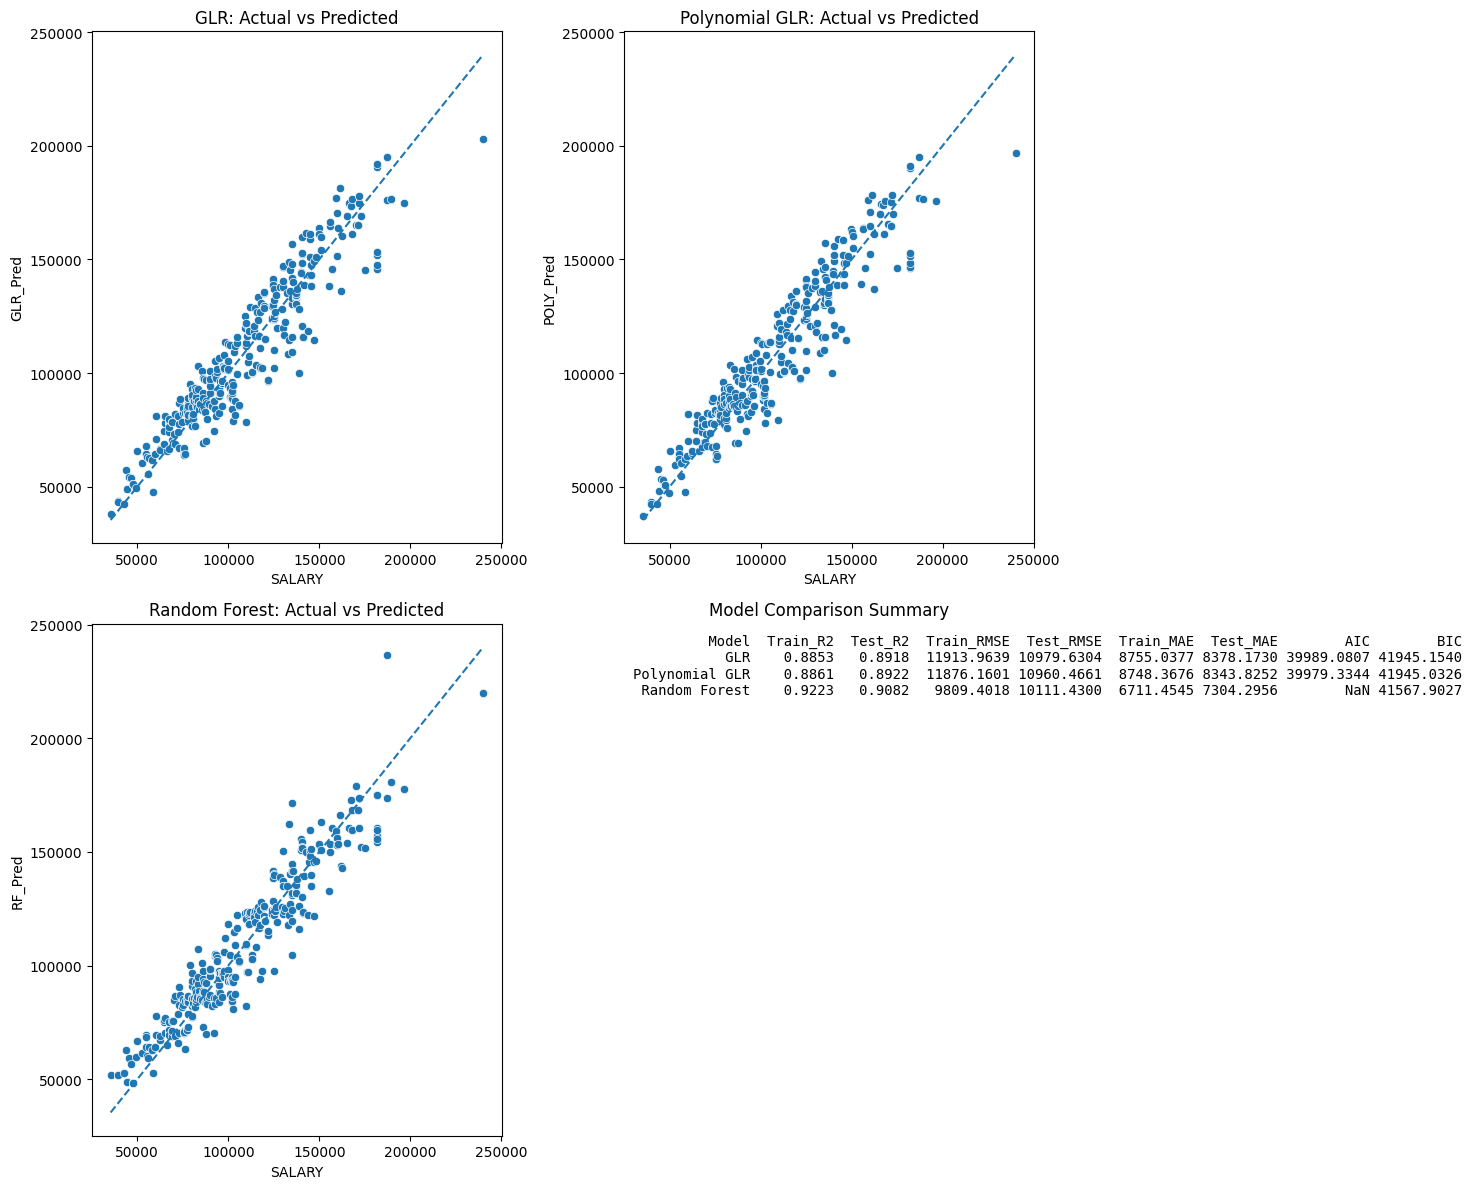

In [33]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

sns.scatterplot(ax=axes[0, 0], data=pred_pd, x="SALARY", y="GLR_Pred")
axes[0, 0].set_title("GLR: Actual vs Predicted")
axes[0, 0].plot(
    [pred_pd["SALARY"].min(), pred_pd["SALARY"].max()],
    [pred_pd["SALARY"].min(), pred_pd["SALARY"].max()],
    linestyle="--"
)

sns.scatterplot(ax=axes[0, 1], data=pred_pd, x="SALARY", y="POLY_Pred")
axes[0, 1].set_title("Polynomial GLR: Actual vs Predicted")
axes[0, 1].plot(
    [pred_pd["SALARY"].min(), pred_pd["SALARY"].max()],
    [pred_pd["SALARY"].min(), pred_pd["SALARY"].max()],
    linestyle="--"
)

sns.scatterplot(ax=axes[1, 0], data=pred_pd, x="SALARY", y="RF_Pred")
axes[1, 0].set_title("Random Forest: Actual vs Predicted")
axes[1, 0].plot(
    [pred_pd["SALARY"].min(), pred_pd["SALARY"].max()],
    [pred_pd["SALARY"].min(), pred_pd["SALARY"].max()],
    linestyle="--"
)

axes[1, 1].axis("off")
axes[1, 1].text(
    0.02, 0.98,
    model_compare.round(4).to_string(index=False),
    fontsize=10,
    family="monospace",
    va="top"
)
axes[1, 1].set_title("Model Comparison Summary")

plt.tight_layout()
plt.savefig("_output/model_comparison_grid.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
glr_results_table.to_csv("_output/glr_coefficients.csv", index=False)
poly_results_table.to_csv("_output/poly_coefficients.csv", index=False)
model_compare.to_csv("_output/model_comparison.csv", index=False)
pred_pd.to_csv("_output/predictions.csv", index=False)
rf_importance_df.to_csv("_output/rf_feature_importance_top10.csv", index=False)